# Import libraries

In [ ]:
!pip install -q diffusers

In [ ]:
!gdown 194DqJkUjjtlUCp7Sd2DkXgwu7SuBFsrj

!unzip -q celeba_hq_256.zip

Downloading...
From (original): https://drive.google.com/uc?id=194DqJkUjjtlUCp7Sd2DkXgwu7SuBFsrj
From (redirected): https://drive.google.com/uc?id=194DqJkUjjtlUCp7Sd2DkXgwu7SuBFsrj&confirm=t&uuid=2d08eef9-26dc-4093-aa94-efadf56dc1be
To: /content/celeba_hq_256.zip
100% 297M/297M [00:05<00:00, 51.8MB/s]


In [ ]:
import os
import random
import math
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
from torchvision.transforms import ToPILImage

from diffusers import UNet2DModel

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
IMG_DIR = "./celeba_hq_256"

SEED = 42

TRAIN_RATIO = 0.9
TRAIN_SIZE = 10000
TEST_SIZE = 100
BATCH_SIZE = 256

IMAGE_SIZE = 64


# UNET Config

UNET_BLOCK_OUT_CHANNELS = (128, 128, 256, 256)

UNET_DOWN_BLOCK_TYPES = (
    "DownBlock2D",
    "DownBlock2D",
    "AttnDownBlock2D",
    "DownBlock2D",
)

UNET_UP_BLOCK_TYPES = (
    "UpBlock2D",
    "AttnUpBlock2D",
    "UpBlock2D",
    "UpBlock2D",
)

LAYERS_PER_BLOCK = 2

In [ ]:
def set_seed(seed=42):
	random.seed(seed)
	os.environ['PYTHONHASHSEED'] = str(seed)
	np.random.seed(seed)

	torch.manual_seed(seed)

	if torch.backends.mps.is_available():
		torch.mps.manual_seed(seed)
		os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

	if torch.cuda.is_available():
		torch.cuda.manual_seed(seed)
		torch.cuda.manual_seed_all(seed)
		torch.backends.cudnn.deterministic = True
		torch.backends.cudnn.benchmark = False

	try:
		torch.use_deterministic_algorithms(True)
	except RuntimeError:
		pass

set_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Utils

In [ ]:
def denormalize(x):
    # Convert [-1, 1] -> [0, 1]
    return (x + 1) / 2


def show_batch(images, nrow=8, title=None):
    images = denormalize(images.detach().cpu()).clamp(0, 1)
    grid = make_grid(images, nrow=nrow, padding=2)
    img = ToPILImage()(grid)

    plt.figure(figsize=(14, 6))
    if title is not None:
        plt.title(title)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


def compose_inpaint(pred_image, masked_image, mask):
    return masked_image * (1 - mask) + pred_image * mask

In [ ]:
def masked_mae_loss(pred, target, mask, eps=1e-8):
    """
    Tính MAE trung bình chỉ trên vùng mask.
    pred, target: [B, 3, H, W]
    mask: [B, 1, H, W]
    """
    loss = torch.abs(pred - target) * mask
    return loss.sum() / (mask.sum() * pred.shape[1] + eps)


def masked_mse_loss(pred, target, mask, eps=1e-8):
    """
    Tính MSE trung bình chỉ trên vùng mask.
    """
    loss = ((pred - target) ** 2) * mask
    return loss.sum() / (mask.sum() * pred.shape[1] + eps)


In [ ]:
def build_unet_7ch():
    model = UNet2DModel(
        sample_size=IMAGE_SIZE,
        in_channels=7,
        out_channels=3,
        layers_per_block=LAYERS_PER_BLOCK,
        block_out_channels=UNET_BLOCK_OUT_CHANNELS,
        down_block_types=UNET_DOWN_BLOCK_TYPES,
        up_block_types=UNET_UP_BLOCK_TYPES,
    )
    return model

In [ ]:
def load_checkpoint(
    checkpoint_path,
    model_type,
    device,
    image_size=256,
    z_dim=256,
    channels=(64, 128, 256, 256),
):
    """
    model_type:
        "vae"
        "diffusion"
        "flow"
    """

    model_type = model_type.lower()

    if model_type in ["flow", "flowmatching", "flow_matching"]:
        model = build_unet_7ch().to(device)

    else:
        raise ValueError(
            f"Unknown model_type={model_type}. "
            "Use 'vae', 'diffusion', or 'flow'."
        )

    state_dict = torch.load(
        checkpoint_path,
        map_location=device
    )

    model.load_state_dict(state_dict)
    model.eval()

    print(f"Loaded {model_type} checkpoint from: {checkpoint_path}")

    return model

# Dataset & Dataloader

In [ ]:
def bbox2mask(img_shape, bbox, dtype="uint8"):
    """
    bbox = (top, left, height, width)
    mask = 1 ở vùng bị che, 0 ở vùng giữ lại.
    """
    height, width = img_shape[:2]

    mask = np.zeros((height, width, 1), dtype=dtype)
    mask[
        bbox[0]:bbox[0] + bbox[2],
        bbox[1]:bbox[1] + bbox[3],
        :
    ] = 1

    return mask

In [ ]:
class InpaintingDataset(Dataset):
    def __init__(self, img_paths, image_size=(256, 256), random_mask=False):
        self.img_paths = img_paths
        self.image_size = image_size
        self.random_mask = random_mask

        self.tfs = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]
            )
        ])

    def __len__(self):
        return len(self.img_paths)

    def get_mask(self):
        h, w = self.image_size

        if self.random_mask:
            mask_h = random.randint(h // 4, h // 2)
            mask_w = random.randint(w // 4, w // 2)

            top = random.randint(0, h - mask_h)
            left = random.randint(0, w - mask_w)
        else:
            mask_h = h // 3
            mask_w = w // 3

            top = (h - mask_h) // 2
            left = (w - mask_w) // 2

        mask = bbox2mask(
            self.image_size,
            bbox=(top, left, mask_h, mask_w)
        )

        mask = torch.from_numpy(mask).permute(2, 0, 1).float()
        return mask

    def __getitem__(self, index):
        img_path = self.img_paths[index]

        img = Image.open(img_path).convert("RGB")
        gt_image = self.tfs(img)

        mask = self.get_mask()

        cond_image = gt_image * (1 - mask) + (-1.0) * mask

        return {
            "gt_image": gt_image,
            "cond_image": cond_image,
            "mask": mask,
            "path": img_path,
        }

In [ ]:
file_names = sorted(os.listdir(IMG_DIR))
img_paths = [os.path.join(IMG_DIR, f) for f in file_names]

random.shuffle(img_paths)

split_idx = int(len(img_paths) * TRAIN_RATIO)

train_imgpaths = img_paths[:split_idx]
val_imgpaths = img_paths[split_idx:]

# Using small data for training, the original dataset is very large
train_imgpaths = train_imgpaths[:TRAIN_SIZE]
val_imgpaths = val_imgpaths[:TEST_SIZE]

print("Train:", len(train_imgpaths))
print("Val:", len(val_imgpaths))

Train: 10000
Val: 100


In [ ]:
train_dataset = InpaintingDataset(
    train_imgpaths,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    random_mask=False,
)

val_dataset = InpaintingDataset(
    val_imgpaths,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    random_mask=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    drop_last=False,
)

print("Train loader:", len(train_loader))
print("Val loader:", len(val_loader))

Train loader: 39
Val loader: 1


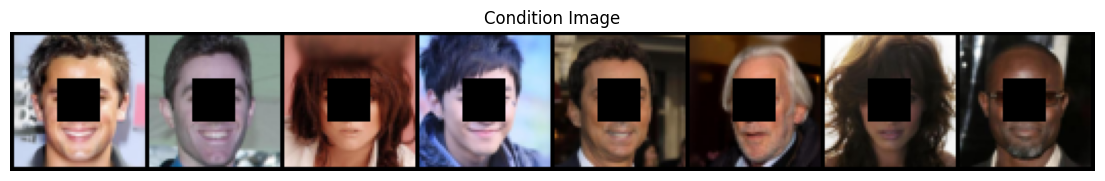

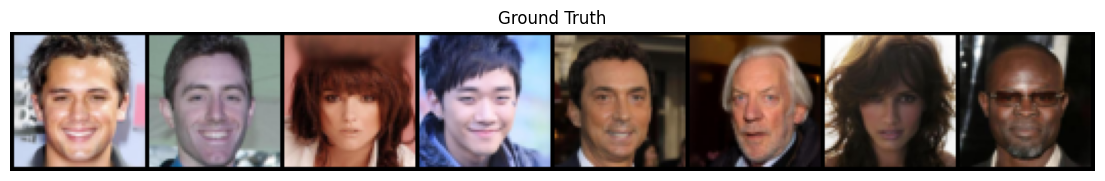

In [ ]:
sample = next(iter(train_loader))

gt_image = sample["gt_image"]
cond_image = sample["cond_image"]
mask = sample["mask"]

show_batch(cond_image[:8], nrow=8, title="Condition Image")
show_batch(gt_image[:8], nrow=8, title="Ground Truth")

# Model

## Model definition

In [ ]:
flow_matching_model = build_unet_7ch().to(device)

flow_optimizer = torch.optim.AdamW(
    flow_matching_model.parameters(),
    lr=5e-5,
    weight_decay=1e-3,
)

total_params = sum(
    p.numel() for p in flow_matching_model.parameters()
    if p.requires_grad
)
print(f"Flow matching total parameters: {total_params:,}")

os.makedirs("Flow Matching", exist_ok=True)

Flow matching total parameters: 28,486,915


## Trainer

In [ ]:
def flow_matching_train_step(
    model,
    data,
    optimizer,
    device,
    lambda_recon=0.0,
):
    model.train()

    gt_image = data["gt_image"].to(device)
    cond_image = data["cond_image"].to(device)
    mask = data["mask"].to(device).float()

    batch_size = gt_image.size(0)

    # x0: source distribution
    # known region sạch, missing region là Gaussian noise
    z = torch.randn_like(gt_image)
    x0 = gt_image * (1 - mask) + z * mask

    # x1: target image
    x1 = gt_image

    # sample t trong [0, 1]
    t = torch.rand(
        batch_size,
        1,
        1,
        1,
        device=device
    )

    # linear path
    x_t = (1 - t) * x0 + t * x1

    # ép known region sạch
    x_t = gt_image * (1 - mask) + x_t * mask

    # target velocity
    v_target = (x1 - x0) * mask

    # input: [x_t, cond_image, mask]
    model_input = torch.cat(
        [x_t, cond_image, mask],
        dim=1
    )

    # UNet2DModel cần timestep embedding dạng [B]
    t_model = t.view(batch_size) * 999.0

    v_pred = model(
        model_input,
        t_model
    ).sample

    loss_flow = masked_mse_loss(
        v_pred,
        v_target,
        mask
    )

    loss = loss_flow
    loss_recon_value = 0.0

    if lambda_recon > 0:
        # Chỉ reconstruct vùng mask
        x1_hat = x_t + (1 - t) * v_pred * mask

        loss_recon = masked_mae_loss(
            x1_hat,
            gt_image,
            mask
        )

        loss = loss + lambda_recon * loss_recon
        loss_recon_value = loss_recon.item()

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    return {
        "loss": loss.item(),
        "loss_flow": loss_flow.item(),
        "loss_recon": loss_recon_value,
    }

## Evaluate

In [ ]:
@torch.no_grad()
def evaluate_flow_matching(
    model,
    val_loader,
    device,
    lambda_recon=0.0,
):
    model.eval()

    total_loss = 0.0
    total_flow_loss = 0.0
    total_recon_loss = 0.0

    for data in val_loader:
        gt_image = data["gt_image"].to(device)
        cond_image = data["cond_image"].to(device)
        mask = data["mask"].to(device).float()

        batch_size = gt_image.size(0)

        z = torch.randn_like(gt_image)
        x0 = gt_image * (1 - mask) + z * mask
        x1 = gt_image

        t = torch.rand(
            batch_size,
            1,
            1,
            1,
            device=device
        )

        x_t = (1 - t) * x0 + t * x1
        x_t = gt_image * (1 - mask) + x_t * mask

        v_target = (x1 - x0) * mask

        model_input = torch.cat(
            [x_t, cond_image, mask],
            dim=1
        )

        t_model = t.view(batch_size) * 999.0

        v_pred = model(
            model_input,
            t_model
        ).sample

        loss_flow = masked_mse_loss(
            v_pred,
            v_target,
            mask
        )

        loss = loss_flow
        loss_recon_value = 0.0

        if lambda_recon > 0:
            # Chỉ reconstruct vùng mask
            x1_hat = x_t + (1 - t) * v_pred * mask

            loss_recon = masked_mae_loss(
                x1_hat,
                gt_image,
                mask
            )

            loss = loss + lambda_recon * loss_recon
            loss_recon_value = loss_recon.item()

        total_loss += loss.item()
        total_flow_loss += loss_flow.item()
        total_recon_loss += loss_recon_value

    return {
        "val_loss": total_loss / len(val_loader),
        "val_flow_loss": total_flow_loss / len(val_loader),
        "val_recon_loss": total_recon_loss / len(val_loader),
    }

## Training

In [ ]:
flow_epochs = 100
best_val_loss = float("inf")

lambda_recon = 0.1

patience = 10
epochs_no_improve = 0

for epoch in range(flow_epochs):
    flow_matching_model.train()

    total_loss = 0.0
    total_flow_loss = 0.0
    total_recon_loss = 0.0

    pbar = tqdm(
        train_loader,
        desc=f"[Flow Matching] Epoch {epoch + 1}/{flow_epochs}"
    )

    for data in pbar:
        metrics = flow_matching_train_step(
            model=flow_matching_model,
            data=data,
            optimizer=flow_optimizer,
            device=device,
            lambda_recon=lambda_recon,
        )

        total_loss += metrics["loss"]
        total_flow_loss += metrics["loss_flow"]
        total_recon_loss += metrics["loss_recon"]

        pbar.set_postfix({
            "loss": metrics["loss"],
            "flow": metrics["loss_flow"],
            "recon": metrics["loss_recon"],
        })

    train_loss = total_loss / len(train_loader)
    train_flow_loss = total_flow_loss / len(train_loader)
    train_recon_loss = total_recon_loss / len(train_loader)

    val_metrics = evaluate_flow_matching(
        model=flow_matching_model,
        val_loader=val_loader,
        device=device,
        lambda_recon=lambda_recon,
    )

    print(
        f"[Flow Matching] Epoch {epoch + 1}: "
        f"train_loss={train_loss:.5f}, "
        f"train_flow_loss={train_flow_loss:.5f}, "
        f"train_recon_loss={train_recon_loss:.5f}, "
        f"val_loss={val_metrics['val_loss']:.5f}, "
        f"val_flow_loss={val_metrics['val_flow_loss']:.5f}, "
        f"val_recon_loss={val_metrics['val_recon_loss']:.5f}"
    )

    if (epoch + 1) % 10 == 0:
        torch.save(
            flow_matching_model.state_dict(),
            f"Flow Matching/flow_epoch_{epoch + 1}.pth"
        )

    if val_metrics["val_loss"] < best_val_loss:
        best_val_loss = val_metrics["val_loss"]
        epochs_no_improve = 0

        torch.save(
            flow_matching_model.state_dict(),
            "Flow Matching/flow_best.pth"
        )

        print(
            f"Saved best Flow Matching checkpoint at epoch {epoch + 1} "
            f"with val_loss={best_val_loss:.5f}"
        )

    else:
        epochs_no_improve += 1

        print(
            f"No improvement for {epochs_no_improve}/{patience} epochs. "
            f"Best val_loss={best_val_loss:.5f}"
        )

        if epochs_no_improve >= patience:
            print(
                f"Early stopping at epoch {epoch + 1}. "
                f"Best val_loss={best_val_loss:.5f}"
            )
            break

[Flow Matching] Epoch 1/100: 100%|██████████| 39/39 [00:22<00:00,  1.71it/s, loss=0.306, flow=0.286, recon=0.195]


[Flow Matching] Epoch 1: train_loss=0.63056, train_flow_loss=0.60298, train_recon_loss=0.27581, val_loss=0.34645, val_flow_loss=0.32737, val_recon_loss=0.19073
Saved best Flow Matching checkpoint at epoch 1 with val_loss=0.34645


[Flow Matching] Epoch 2/100: 100%|██████████| 39/39 [00:22<00:00,  1.73it/s, loss=0.271, flow=0.256, recon=0.152]


[Flow Matching] Epoch 2: train_loss=0.28694, train_flow_loss=0.27053, train_recon_loss=0.16411, val_loss=0.25638, val_flow_loss=0.24210, val_recon_loss=0.14273
Saved best Flow Matching checkpoint at epoch 2 with val_loss=0.25638


[Flow Matching] Epoch 3/100: 100%|██████████| 39/39 [00:22<00:00,  1.73it/s, loss=0.219, flow=0.205, recon=0.134]


...

[Flow Matching] Epoch 39: train_loss=0.08114, train_flow_loss=0.07496, train_recon_loss=0.06183, val_loss=0.12570, val_flow_loss=0.11784, val_recon_loss=0.07857
No improvement for 8/10 epochs. Best val_loss=0.08501


[Flow Matching] Epoch 40/100: 100%|██████████| 39/39 [00:22<00:00,  1.73it/s, loss=0.0861, flow=0.0804, recon=0.0573]


[Flow Matching] Epoch 40: train_loss=0.07912, train_flow_loss=0.07306, train_recon_loss=0.06066, val_loss=0.10303, val_flow_loss=0.09531, val_recon_loss=0.07722
No improvement for 9/10 epochs. Best val_loss=0.08501


[Flow Matching] Epoch 41/100: 100%|██████████| 39/39 [00:22<00:00,  1.73it/s, loss=0.0947, flow=0.0885, recon=0.0621]


[Flow Matching] Epoch 41: train_loss=0.08150, train_flow_loss=0.07528, train_recon_loss=0.06216, val_loss=0.11940, val_flow_loss=0.11095, val_recon_loss=0.08447
No improvement for 10/10 epochs. Best val_loss=0.08501
Early stopping at epoch 41. Best val_loss=0.08501


## Inference

In [ ]:
@torch.no_grad()
def flow_matching_inpaint(
    model,
    cond_image,
    mask,
    num_steps=100,
    device=None,
):
    model.eval()

    if device is None:
        device = cond_image.device

    cond_image = cond_image.to(device)
    mask = mask.to(device).float()

    # cond_image: known region giữ ảnh thật, missing region = -1
    # visible_image: known region giữ ảnh thật, missing region = 0
    visible_image = cond_image * (1 - mask)

    # y0: known region sạch, missing region là Gaussian noise
    y = torch.randn_like(cond_image)
    y = visible_image + y * mask

    t_steps = torch.linspace(
        0.0,
        1.0,
        num_steps,
        device=device
    )

    batch_size = y.size(0)

    for i in tqdm(range(num_steps - 1), desc="Flow Matching Euler Sampling"):
        t = t_steps[i]
        t_next = t_steps[i + 1]
        dt = t_next - t

        # Ép known region sạch trước khi predict
        y = visible_image + y * mask

        model_input = torch.cat(
            [y, cond_image, mask],
            dim=1
        )

        t_model = torch.full(
            (batch_size,),
            float(t.item() * 999.0),
            device=device,
            dtype=torch.float32,
        )

        v = model(
            model_input,
            t_model
        ).sample

        # Chỉ update vùng mask
        y = y + v * dt * mask

        # Ép known region sạch sau update
        y = visible_image + y * mask

    return y.clamp(-1, 1)

In [ ]:
flow_matching_model = load_checkpoint(
    checkpoint_path="/content/Flow Matching/flow_best.pth",
    model_type="flow_matching",
    device=device,
)

flow_matching_model.eval()

all_gt = []
all_cond = []
all_result = []

for batch_idx, sample in enumerate(val_loader):
    gt_image = sample["gt_image"].to(device)
    cond_image = sample["cond_image"].to(device)
    mask = sample["mask"].to(device).float()

    flow_result = flow_matching_inpaint(
        model=flow_matching_model,
        cond_image=cond_image,
        mask=mask,
        num_steps=150,
        device=device,
    )

    all_gt.append(gt_image.detach().cpu())
    all_cond.append(cond_image.detach().cpu())
    all_result.append(flow_result.detach().cpu())

all_gt = torch.cat(all_gt, dim=0)
all_cond = torch.cat(all_cond, dim=0)
all_result = torch.cat(all_result, dim=0)

print("Generated:", all_result.shape)

Loaded flow_matching checkpoint from: /content/Flow Matching/flow_best.pth


Flow Matching Euler Sampling: 100%|██████████| 149/149 [00:11<00:00, 12.88it/s]


Generated: torch.Size([100, 3, 64, 64])


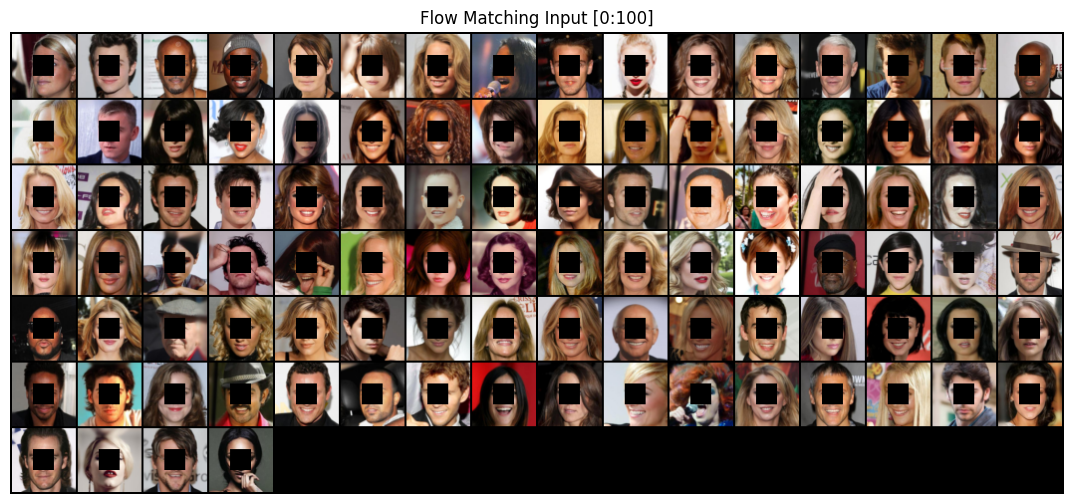

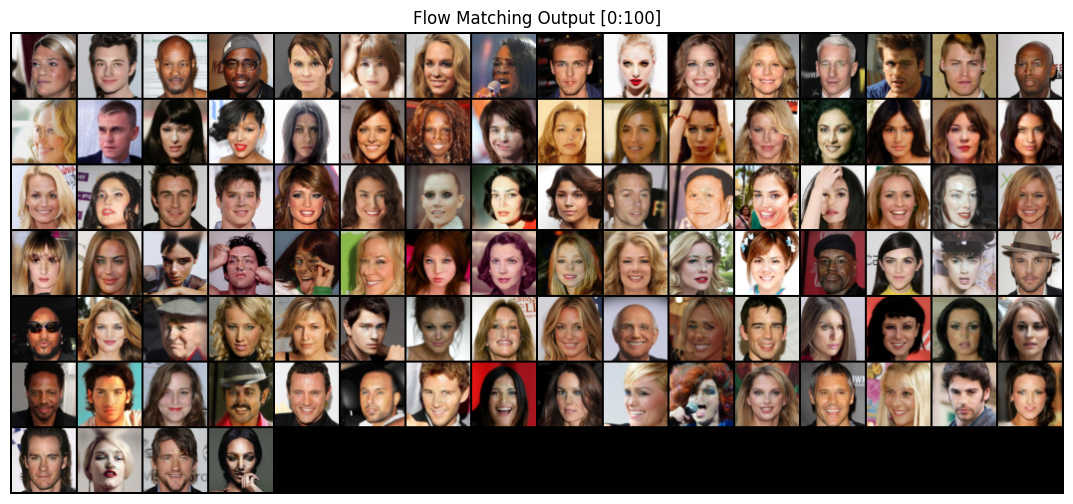

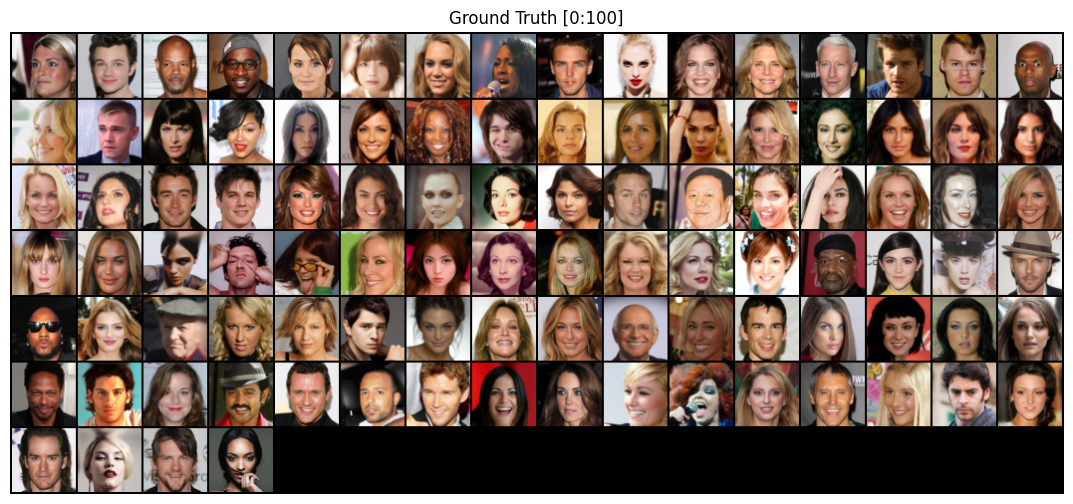

In [ ]:
num_images = all_result.size(0)
display_batch = BATCH_SIZE

for start in range(0, num_images, display_batch):
    end = min(start + display_batch, num_images)

    show_batch(
        all_cond[start:end],
        nrow=16,
        title=f"Flow Matching Input [{start}:{end}]"
    )

    show_batch(
        all_result[start:end],
        nrow=16,
        title=f"Flow Matching Output [{start}:{end}]"
    )

    show_batch(
        all_gt[start:end],
        nrow=16,
        title=f"Ground Truth [{start}:{end}]"
    )